<a href="https://colab.research.google.com/github/natdanaiii/Trading/blob/main/Grid_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Test

In [ ]:
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_PATH = '/content/drive/MyDrive/03.Trading/00.Live Trading'
print(f"Project path set to: {PROJECT_PATH}")

Mounted at /content/drive
Project path set to: /content/drive/MyDrive/03.Trading/00.Live Trading


In [ ]:
SYMBOL = "BTCUSDT"

START_DATE = "2024-01-01"
END_DATE   = "2026-01-01"

TIMEFRAMES = ["1m", "1h", "1d"]

SAVE_DIR = "/content/drive/MyDrive/03.Trading/00.Live Trading"

In [ ]:
# import os
# import datetime

# def download_binance_history(symbol, start_date_str, end_date_str, timeframes, save_dir):
#     start_date = datetime.datetime.strptime(start_date_str, "%Y-%m-%d")
#     end_date = datetime.datetime.strptime(end_date_str, "%Y-%m-%d")

#     if not os.path.exists(save_dir):
#         os.makedirs(save_dir)

#     current_date = start_date
#     while current_date < end_date:
#         year = current_date.year
#         month = current_date.month

#         for tf in timeframes:
#             url = (f"https://data.binance.vision/data/spot/monthly/klines/"
#                    f"{symbol}/{tf}/{symbol}-{tf}-{year}-{month:02d}.zip")

#             try:
#                 print(f"Downloading {symbol} {tf} for {year}-{month:02d}...")
#                 response = requests.get(url)
#                 response.raise_for_status()

#                 columns = ["open_time", "open", "high", "low", "close", "volume",
#                            "close_time", "quote_volume", "number_of_trades",
#                            "taker_buy_base", "taker_buy_quote", "ignore"]

#                 df = pd.read_csv(io.BytesIO(response.content), compression="zip",
#                                  header=None, names=columns)

#                 time_unit = "us" if year >= 2025 else "ms"
#                 df["open_time"] = pd.to_datetime(df["open_time"], unit=time_unit, utc=True)
#                 df["close_time"] = pd.to_datetime(df["close_time"], unit=time_unit, utc=True)

#                 numeric_cols = ["open", "high", "low", "close", "volume"]
#                 df[numeric_cols] = df[numeric_cols].astype(float)

#                 save_path = os.path.join(save_dir, f"{symbol}-{tf}-{year}-{month:02d}.csv")
#                 df.to_csv(save_path, index=False)
#                 print(f"  Successfully saved to {save_path}")
#             except Exception as e:
#                 print(f"  Could not download {year}-{month:02d} {tf}: {e}")

#         # Move to next month
#         if current_date.month == 12:
#             current_date = current_date.replace(year=current_date.year + 1, month=1)
#         else:
#             current_date = current_date.replace(month=current_date.month + 1)

# download_binance_history(SYMBOL, START_DATE, END_DATE, TIMEFRAMES, SAVE_DIR)

In [ ]:
# import glob

# for tf in TIMEFRAMES:
#     # Find all files for this timeframe
#     search_pattern = os.path.join(SAVE_DIR, f"{SYMBOL}-{tf}-*.csv")
#     file_list = sorted(glob.glob(search_pattern))

#     if not file_list:
#         print(f"No files found for timeframe: {tf}")
#         continue

#     print(f"Combining {len(file_list)} files for {tf}...")

#     # Load and concatenate all CSVs
#     combined_df = pd.concat([pd.read_csv(f) for f in file_list], ignore_index=True)

#     # Ensure chronological order
#     combined_df['open_time'] = pd.to_datetime(combined_df['open_time'])
#     combined_df = combined_df.sort_values('open_time')

#     # Save the consolidated file
#     output_filename = f"{SYMBOL}-{tf}-combined.csv"
#     output_path = os.path.join(SAVE_DIR, output_filename)
#     combined_df.to_csv(output_path, index=False)

#     print(f"Successfully created: {output_path} ({len(combined_df)} rows)")

In [ ]:
file_path = os.path.join(SAVE_DIR, "BTCUSDT-1m-combined.csv")
df_check = pd.read_csv(file_path)
df_check.head()

,open_time,open,high,low,close,volume,close_time,quote_volume,number_of_trades,taker_buy_base,taker_buy_quote,ignore
0,2024-01-01 00:00:00+00:00,42283.58,42298.62,42261.02,42298.61,35.92724,2024-01-01 00:00:59.999000+00:00,1.519032e+06,1327,23.18766,9.803947e+05,0
1,2024-01-01 00:01:00+00:00,42298.62,42320.00,42298.61,42320.00,21.16779,2024-01-01 00:01:59.999000+00:00,8.955809e+05,1348,13.47483,5.700808e+05,0
2,2024-01-01 00:02:00+00:00,42319.99,42331.54,42319.99,42325.50,21.60391,2024-01-01 00:02:59.999000+00:00,9.143711e+05,1019,11.21801,4.747986e+05,0
3,2024-01-01 00:03:00+00:00,42325.50,42368.00,42325.49,42367.99,30.50730,2024-01-01 00:03:59.999000+00:00,1.291997e+06,1241,24.04878,1.018449e+06,0
4,2024-01-01 00:04:00+00:00,42368.00,42397.23,42367.99,42397.23,46.05107,2024-01-01 00:04:59.999000+00:00,1.951945e+06,1415,34.12804,1.446539e+06,0


In [ ]:
import pandas as pd
import numpy as np

# 1. Load and Prepare Data
def load_data(file_path):
    cols = ['open_time', 'open', 'high', 'low', 'close', 'volume',
            'close_time', 'quote_volume', 'count', 'taker_buy_volume',
            'taker_buy_quote_volume', 'ignore']

    df = pd.read_csv(file_path, names=cols, header=0)

    # แก้ไข: ลบ unit='ms' ออก เพื่อให้อ่านวันที่แบบ String ได้โดยตรง
    df['open_time'] = pd.to_datetime(df['open_time'])
    df.set_index('open_time', inplace=True)

    return df[['open', 'high', 'low', 'close']]


In [ ]:
import pandas as pd
import numpy as np

def add_atr_and_dynamic_gap(df, fee_pct=0.001, atr_period=14, profit_buffer=1.5):
    # 1. คำนวณ True Range (TR)
    df['prev_close'] = df['close'].shift(1)
    df['tr'] = np.maximum((df['high'] - df['low']),
               np.maximum(abs(df['high'] - df['prev_close']),
                          abs(df['low'] - df['prev_close'])))

    # 2. คำนวณ ATR (ค่าเฉลี่ยความผันผวน)
    df['atr'] = df['tr'].rolling(window=atr_period).mean()

    # 3. คำนวณ Minimum Gap ที่รอดพ้นค่าธรรมเนียมแน่นอน
    # สมมติ Fee 0.1% ไป-กลับคือ 0.2% -> คูณ profit_buffer 1.5 เพื่อให้เหลือเศษกำไรเข้าพอร์ต
    total_fee_pct = fee_pct * 2
    df['min_fee_gap'] = df['close'] * total_fee_pct * profit_buffer

    # 4. เลือก Dynamic Gap ที่ใช้งานจริง (เอาค่าที่มากกว่าระหว่าง ATR กับ Min_Gap)
    # หมายเหตุ: อาจจะใช้ ATR/2 หรือ ATR/4 เป็น Gap ขึ้นอยู่กับความถี่ที่อยากเทรด (ในที่นี้ใช้ ATR/2 เบื้องต้น)
    df['dynamic_gap'] = np.maximum(df['atr'] / 2, df['min_fee_gap'])

    return df

# ลองรันข้อมูล 1h ดูความเปลี่ยนแปลงของ Gap
df_1h_atr = add_atr_and_dynamic_gap(df_1h.copy())
print("--- ตัวอย่างค่า Dynamic Gap ---")
print(df_1h_atr[['close', 'atr', 'min_fee_gap', 'dynamic_gap']].dropna().tail(5))

--- ตัวอย่างค่า Dynamic Gap ---
                              close         atr  min_fee_gap  dynamic_gap
open_time                                                                
2025-12-31 19:00:00+00:00  87541.85  384.822857    262.62555    262.62555
2025-12-31 20:00:00+00:00  87662.01  410.789286    262.98603    262.98603
2025-12-31 21:00:00+00:00  87799.97  411.457143    263.39991    263.39991
2025-12-31 22:00:00+00:00  87728.29  403.102857    263.18487    263.18487
2025-12-31 23:00:00+00:00  87648.22  390.817857    262.94466    262.94466


In [ ]:
# --- ตั้งค่าพารามิเตอร์หลัก (Config) ---
CAPITAL = 10000    # เงินทุนรวม
CEILING = 100000   # เพดานราคาสูงสุด
FLOOR = 60000    # พื้นราคาต่ำสุด
GAP = 450         # ระยะห่างแต่ละช่อง
FEE_PCT = 0.001    # ค่าธรรมเนียม (ตัวอย่าง 0.001 คือ 0.1% ของ Binance คู่ USDT)

# --- ฟังก์ชันตรวจสอบค่าธรรมเนียม vs สเปรด ---
def validate_grid_config(capital, ceiling, floor, gap, fee_pct):
    num_levels = int((ceiling - floor) / gap)
    cost_per_level = capital / num_levels

    # ลองจำลองกำไรที่ไม้ Floor (ไม้ที่ได้ Amount เยอะสุด/กำไรต่อ Gap เยอะสุด)
    amount_at_floor = cost_per_level / floor
    gross_profit = amount_at_floor * gap

    # ลองจำลองกำไรที่ไม้ Ceiling (ไม้ที่ได้ Amount น้อยสุด/กำไรต่อ Gap น้อยสุด)
    amount_at_ceiling = cost_per_level / (ceiling - gap)
    worst_gross_profit = amount_at_ceiling * gap

    # ประเมินค่าธรรมเนียมไป-กลับ
    est_buy_fee = cost_per_level * fee_pct
    est_sell_fee = cost_per_level * fee_pct
    total_fee = est_buy_fee + est_sell_fee

    print("--- Grid Configuration Check ---")
    print(f"จำนวนชั้นทั้งหมด (Levels): {num_levels} ชั้น")
    print(f"ใช้ทุนชั้นละ (Cost per level): {cost_per_level:.2f} USDT")
    print(f"ค่าธรรมเนียมไป-กลับ โดยประมาณ: {total_fee:.2f} USDT")
    print(f"กำไรขั้นต่ำต่อ 1 ไม้ (ยังไม่หัก Fee): {worst_gross_profit:.2f} USDT")

    if worst_gross_profit <= total_fee:
        print("⚠️ คำเตือน: Gap แคบเกินไป ค่าธรรมเนียมจะกินกำไรจนหมดหรือขาดทุน!")
    else:
        print("✅ Config ผ่าน: Gap กว้างพอที่จะครอบคลุมค่าธรรมเนียม 2 ขา")
    print("-" * 30)

# รันตรวจสอบ Config
validate_grid_config(CAPITAL, CEILING, FLOOR, GAP, FEE_PCT)

# รันสร้าง Grid Zones โดยส่งค่า FEE_PCT เข้าไปด้วย
df_grid = generate_grid_zones(CAPITAL, CEILING, FLOOR, GAP, FEE_PCT)

# สั่งรัน Execution Engine โดยส่ง FEE_PCT เข้าไปด้วยเช่นกัน
df_log, total_cashflow, df_final_grid = run_grid_backtest(df_1h, df_grid, GAP, FEE_PCT)

print("\n--- Trade Log Sample ---")
print(df_log.head(5) if not df_log.empty else "No trades executed.")
print(f"\nTotal Cashflow Generated: {total_cashflow:.2f} USDT")
print(f"Total Transactions: {len(df_log)} trades")

--- Grid Configuration Check ---
จำนวนชั้นทั้งหมด (Levels): 88 ชั้น
ใช้ทุนชั้นละ (Cost per level): 113.64 USDT
ค่าธรรมเนียมไป-กลับ โดยประมาณ: 0.23 USDT
กำไรขั้นต่ำต่อ 1 ไม้ (ยังไม่หัก Fee): 0.51 USDT
✅ Config ผ่าน: Gap กว้างพอที่จะครอบคลุมค่าธรรมเนียม 2 ขา
------------------------------

--- Trade Log Sample ---
                       time action  grid_price  executed_price  cashflow
0 2024-02-28 13:00:00+00:00    BUY       60450           60450  0.000000
1 2024-02-28 13:00:00+00:00    BUY       60000           60000  0.000000
2 2024-02-28 14:00:00+00:00   SELL       60450           60900  0.617810
3 2024-02-28 14:00:00+00:00   SELL       60000           60450  0.624148
4 2024-02-28 14:00:00+00:00    BUY       60900           60900  0.000000

Total Cashflow Generated: 2214.18 USDT
Total Transactions: 10652 trades


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- อัปเดต Step 2: Execution Engine (เพิ่ม Portfolio Tracking) ---
def run_grid_backtest_with_port(df_price, df_grid, gap, capital, fee_pct=0.001):
    grids = df_grid.to_dict('records')
    for g in grids:
        g['sell_target'] = g['price'] + gap

    trade_log = []
    port_history = [] # เก็บประวัติมูลค่าพอร์ตทุกๆ 1 แท่งเทียน

    current_cash = capital
    current_holdings = 0 # จำนวน BTC ที่ถืออยู่
    total_cashflow = 0

    prices = df_price.reset_index()[['open_time', 'low', 'high', 'close']].to_dict('records')

    for p in prices:
        curr_low = p['low']
        curr_high = p['high']
        curr_close = p['close']
        curr_time = p['open_time']

        # 1. เช็ค SELL
        for g in grids:
            if g['status'] == 'held' and curr_high >= g['sell_target']:
                g['status'] = 'empty'

                revenue = g['amount'] * g['sell_target']
                sell_fee = revenue * fee_pct
                actual_earn = (g['amount'] * gap) - g['fee'] - sell_fee

                # คืนเงินเข้าพอร์ต และหัก BTC ออก
                current_cash += (revenue - sell_fee)
                current_holdings -= g['amount']
                total_cashflow += actual_earn

                trade_log.append({
                    'time': curr_time, 'action': 'SELL',
                    'grid_price': g['price'], 'executed_price': g['sell_target'],
                    'cashflow': actual_earn
                })

        # 2. เช็ค BUY
        for g in grids:
            if g['status'] == 'empty' and curr_low <= g['price'] <= curr_high:
                g['status'] = 'held'

                # จ่ายเงินซื้อ (รวมค่าธรรมเนียม) และเก็บ BTC
                total_cost = g['cost_per_level'] + g['fee']
                current_cash -= total_cost
                current_holdings += g['amount']

                trade_log.append({
                    'time': curr_time, 'action': 'BUY',
                    'grid_price': g['price'], 'executed_price': g['price'],
                    'cashflow': 0
                })

        # 3. คำนวณมูลค่าพอร์ตรวมที่ราคาปิดของแท่งเทียนนี้ (Mark-to-Market)
        holdings_value = current_holdings * curr_close
        portfolio_value = current_cash + holdings_value

        port_history.append({
            'time': curr_time,
            'cash': current_cash,
            'holdings_value': holdings_value,
            'portfolio_value': portfolio_value
        })

    df_log = pd.DataFrame(trade_log)
    df_port = pd.DataFrame(port_history).set_index('time')
    df_final_grid = pd.DataFrame(grids)

    return df_log, df_port, total_cashflow, df_final_grid



In [ ]:
# --- อัปเดต Step 3: Visualization (เพิ่มกราฟ Portfolio) ---
def plot_grid_performance_with_port(df_price, df_log, df_port, total_cashflow):
    total_trades = len(df_log)
    buy_trades = len(df_log[df_log['action'] == 'BUY']) if total_trades > 0 else 0
    sell_trades = len(df_log[df_log['action'] == 'SELL']) if total_trades > 0 else 0

    print("--- 📊 Backtest Summary ---")
    print(f"Total Transactions : {total_trades} ไม้ (Buy: {buy_trades} | Sell: {sell_trades})")
    print(f"Total Cashflow     : {total_cashflow:.2f} USDT")
    print(f"Final Port Value   : {df_port['portfolio_value'].iloc[-1]:.2f} USDT")
    print(f"Max Drawdown (Port): {(df_port['portfolio_value'].min() - CAPITAL):.2f} USDT")
    print("-" * 28)

    # # สร้างกราฟ 2 ชั้น (บน=ราคาและการเทรด, ล่าง=มูลค่าพอร์ต)
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # # --- กราฟที่ 1: การเทรด (Price Action & Executions) ---
    # ax1.plot(df_price.index, df_price['close'], label='BTC/USDT', color='black', alpha=0.5, linewidth=1)
    # if not df_log.empty:
    #     buys = df_log[df_log['action'] == 'BUY']
    #     sells = df_log[df_log['action'] == 'SELL']
    #     ax1.scatter(buys['time'], buys['executed_price'], marker='^', color='green', label='Buy', s=40, zorder=3)
    #     ax1.scatter(sells['time'], sells['executed_price'], marker='v', color='red', label='Sell', s=40, zorder=3)
    # ax1.set_title(f'Grid Trading Execution', fontweight='bold')
    # ax1.set_ylabel('Price (USDT)')
    # ax1.legend(loc='upper left')
    # ax1.grid(True, linestyle='--', alpha=0.5)

    # # --- กราฟที่ 2: มูลค่าพอร์ต (Portfolio Value) ---
    # ax2.plot(df_port.index, df_port['portfolio_value'], label='Total Portfolio Value', color='blue', linewidth=1.5)
    # ax2.plot(df_port.index, df_port['cash'], label='Available Cash', color='green', alpha=0.5, linewidth=1)
    # # ขีดเส้นประแสดงทุนเริ่มต้น (Initial Capital)
    # ax2.axhline(CAPITAL, color='red', linestyle='--', alpha=0.7, label='Initial Capital')

    # ax2.set_title('Portfolio Value & Cash Balance', fontweight='bold')
    # ax2.set_ylabel('Value (USDT)')
    # ax2.set_xlabel('Date / Time')
    # ax2.legend(loc='upper left')
    # ax2.grid(True, linestyle='--', alpha=0.5)

    # plt.tight_layout()
    # plt.show()



In [ ]:
# --- สั่งรันระบบใหม่ ---
df_log, df_port, total_cashflow, df_final_grid = run_grid_backtest_with_port(df_1h, df_grid, GAP, CAPITAL, FEE_PCT)
plot_grid_performance_with_port(df_1h, df_log, df_port, total_cashflow)

--- 📊 Backtest Summary ---
Total Transactions : 9784 ไม้ (Buy: 4905 | Sell: 4879)
Total Cashflow     : 1886.57 USDT
Final Port Value   : 11746.64 USDT
Max Drawdown (Port): -115.34 USDT
----------------------------


In [ ]:
import pandas as pd
import numpy as np

def calculate_atr_gap(df, atr_period=14, fee_pct=0.001, profit_buffer=1.5):
    df = df.copy()

    # 1. คำนวณ True Range (TR)
    df['prev_close'] = df['close'].shift(1)
    df['tr'] = np.maximum((df['high'] - df['low']),
               np.maximum(abs(df['high'] - df['prev_close']),
                          abs(df['low'] - df['prev_close'])))

    # 2. คำนวณ ATR (ค่าเฉลี่ยความผันผวน)
    df['atr'] = df['tr'].rolling(window=atr_period).mean()

    # 3. คำนวณ Minimum Gap ที่ครอบคลุมค่าธรรมเนียม
    total_fee_pct = fee_pct * 2
    df['min_fee_gap'] = df['close'] * total_fee_pct * profit_buffer

    # 4. เลือก Dynamic Gap (เทียบระหว่าง ATR กับ Minimum Gap)
    # ในที่นี้ใช้ ATR/2 เป็นระยะสวิงเบื้องต้น
    df['dynamic_gap'] = np.maximum(df['atr'] / 2, df['min_fee_gap'])

    # 5. ปัดเศษให้อ่านง่ายและตั้งออเดอร์ง่าย (ปัดหลักสิบ)
    df['dynamic_gap'] = (df['dynamic_gap'] / 10).round() * 10

    return df

# --- สั่งรัน ---
df_1h_atr = calculate_atr_gap(df_1h)

# แสดงสถิติ
print("--- 📊 สถิติ Dynamic Gap จาก ATR (1H) ---")
print(f"Gap แคบที่สุด : {df_1h_atr['dynamic_gap'].min():.0f} USDT")
print(f"Gap กว้างที่สุด : {df_1h_atr['dynamic_gap'].max():.0f} USDT")
print(f"Gap เฉลี่ย    : {df_1h_atr['dynamic_gap'].mean():.0f} USDT")

print("\n--- ตัวอย่างข้อมูลล่าสุด ---")
print(df_1h_atr[['close', 'atr', 'min_fee_gap', 'dynamic_gap']].dropna().tail())

--- 📊 สถิติ Dynamic Gap จาก ATR (1H) ---
Gap แคบที่สุด : 120 USDT
Gap กว้างที่สุด : 1330 USDT
Gap เฉลี่ย    : 318 USDT

--- ตัวอย่างข้อมูลล่าสุด ---
                              close         atr  min_fee_gap  dynamic_gap
open_time                                                                
2025-12-31 19:00:00+00:00  87541.85  384.822857    262.62555        260.0
2025-12-31 20:00:00+00:00  87662.01  410.789286    262.98603        260.0
2025-12-31 21:00:00+00:00  87799.97  411.457143    263.39991        260.0
2025-12-31 22:00:00+00:00  87728.29  403.102857    263.18487        260.0
2025-12-31 23:00:00+00:00  87648.22  390.817857    262.94466        260.0


#Backup

--- 📊 Backtest Summary ---
Total Transactions : 4445 ไม้ (Buy: 2225 | Sell: 2220)
Total Cashflow     : 193.01 USDT
Final Port Value   : 10175.86 USDT
Max Drawdown (Port): -134.72 USDT
----------------------------


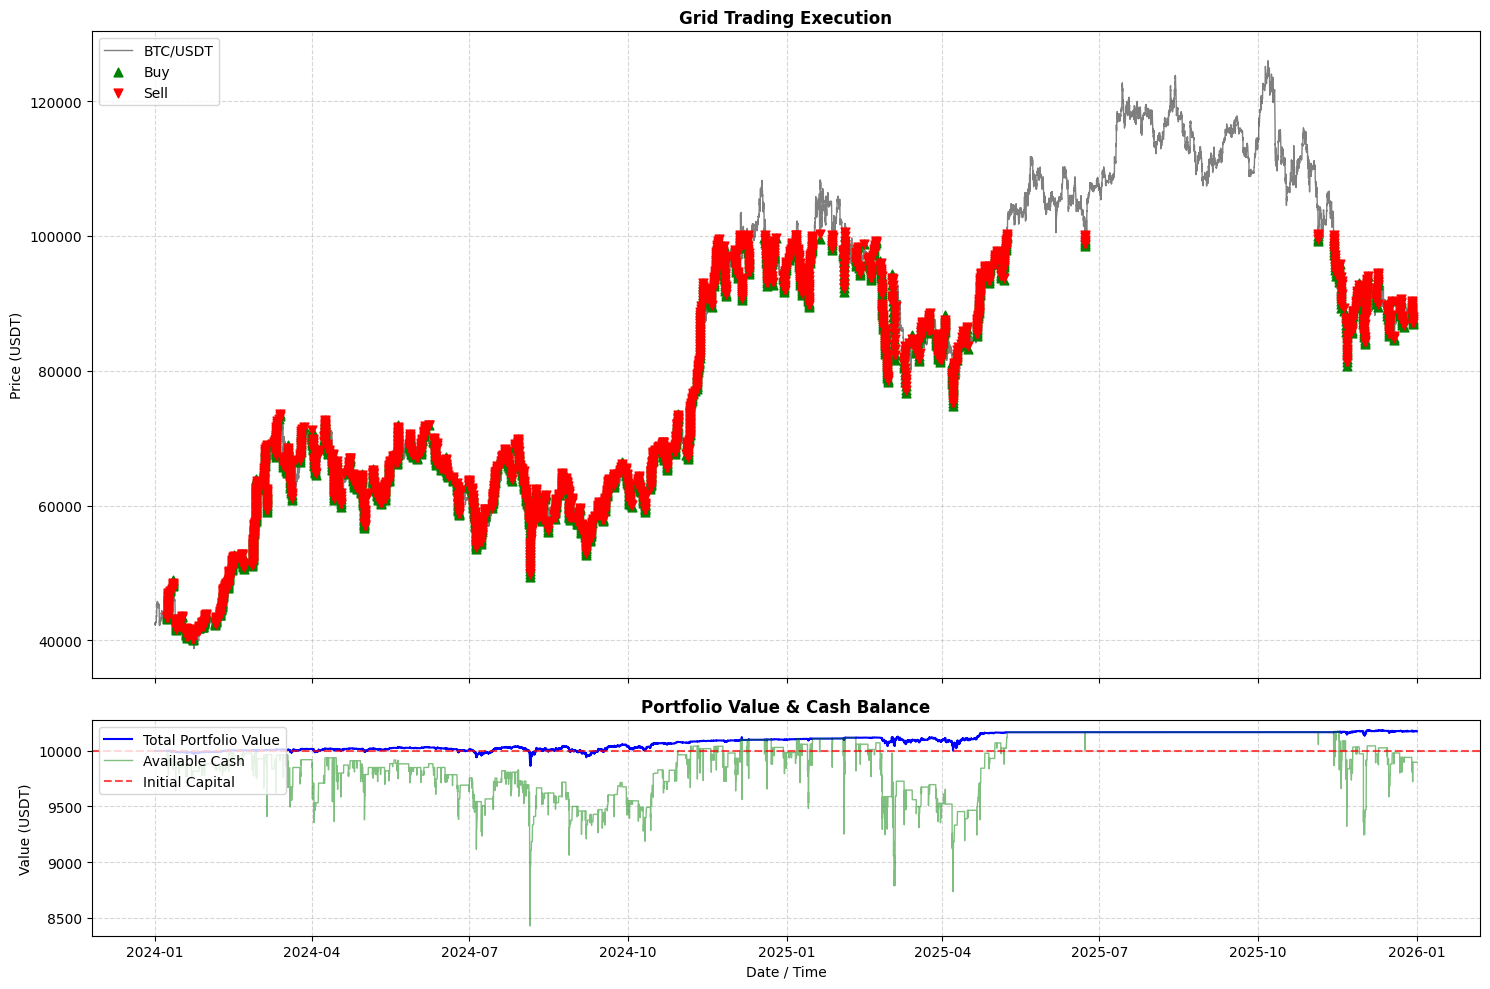

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_dynamic_grid_opt_c(df, capital, ceiling, floor, fee_pct=0.001):
    current_cash = capital
    current_holdings = 0
    total_cashflow = 0
    trade_log = []
    port_history = []

    active_grids = []
    current_week = None

    # ดึงข้อมูลพร้อมค่า Dynamic Gap ที่คำนวณไว้แล้ว
    prices = df.reset_index()[['open_time', 'low', 'high', 'close', 'dynamic_gap']].to_dict('records')

    for p in prices:
        curr_time = p['open_time']
        curr_week = curr_time.isocalendar()[1]
        curr_gap = p['dynamic_gap']

        # --- 1. Weekly Re-Grid (อัปเดตกริดใหม่ทุกสัปดาห์) ---
        if current_week is None or curr_week != current_week:
            current_week = curr_week

            # เก็บไม้ที่ถือของอยู่ (Lock ไม้เก่า)
            held_grids = [g for g in active_grids if g['status'] == 'held']

            # นำเงินสดที่เหลือมาสร้างไม้รอซื้อใหม่ (Empty) ด้วย Gap ใหม่
            if pd.notna(curr_gap) and curr_gap > 0:
                num_levels = int((ceiling - floor) / curr_gap)
                if num_levels > 0:
                    cost_per_level = current_cash / num_levels
                    grid_prices = [floor + (i * curr_gap) for i in range(num_levels + 1)]

                    new_empty_grids = []
                    for price in grid_prices:
                        new_empty_grids.append({
                            'price': price,
                            'amount': cost_per_level / price,
                            'cost_per_level': cost_per_level,
                            'fee': cost_per_level * fee_pct,
                            'sell_target': price + curr_gap,
                            'status': 'empty'
                        })

                    # นำไม้เก่าและไม้ใหม่มารวมกันเป็น Grid ชุดปัจจุบัน
                    active_grids = held_grids + new_empty_grids

        # --- 2. ตรวจสอบเงื่อนไข SELL ---
        for g in active_grids:
            if g['status'] == 'held' and p['high'] >= g['sell_target']:
                g['status'] = 'sold' # มาร์คไว้เพื่อเตรียมลบทิ้ง

                revenue = g['amount'] * g['sell_target']
                sell_fee = revenue * fee_pct
                actual_earn = (g['amount'] * (g['sell_target'] - g['price'])) - g['fee'] - sell_fee

                current_cash += (revenue - sell_fee)
                current_holdings -= g['amount']
                total_cashflow += actual_earn

                trade_log.append({
                    'time': curr_time, 'action': 'SELL',
                    'grid_price': g['price'], 'executed_price': g['sell_target'],
                    'cashflow': actual_earn
                })

        # ล้างไม้ที่เพิ่งขายออกไปจากระบบ (ลบไม้เก่า เงินรอจัดสรรใหม่สัปดาห์หน้า)
        active_grids = [g for g in active_grids if g['status'] != 'sold']

        # --- 3. ตรวจสอบเงื่อนไข BUY ---
        for g in active_grids:
            if g['status'] == 'empty' and p['low'] <= g['price'] <= p['high']:
                total_cost = g['cost_per_level'] + g['fee']
                # เช็คว่ามีเงินสดพอซื้อ (กันกรณี Gap ทับซ้อนกันจนดึงเงินเกิน)
                if current_cash >= total_cost:
                    g['status'] = 'held'
                    current_cash -= total_cost
                    current_holdings += g['amount']

                    trade_log.append({
                        'time': curr_time, 'action': 'BUY',
                        'grid_price': g['price'], 'executed_price': g['price'],
                        'cashflow': 0
                    })

        # --- 4. บันทึกมูลค่าพอร์ตแบบ Real-time ---
        holdings_value = current_holdings * p['close']
        port_history.append({
            'time': curr_time,
            'cash': current_cash,
            'holdings_value': holdings_value,
            'portfolio_value': current_cash + holdings_value
        })

    return pd.DataFrame(trade_log), pd.DataFrame(port_history).set_index('time'), total_cashflow

# --- สั่งรันระบบ Dynamic Grid ---
# ใช้ df_1h_atr ที่เราประมวลผลเพิ่มคอลัมน์ dynamic_gap ไว้ก่อนหน้านี้
df_log_dyn, df_port_dyn, total_cf_dyn = run_dynamic_grid_opt_c(df_1h_atr, CAPITAL, CEILING, FLOOR, FEE_PCT)

# แสดงผลลัพธ์
plot_grid_performance_with_port(df_1h_atr, df_log_dyn, df_port_dyn, total_cf_dyn)